Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0054
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0041
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0040
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0040
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0040
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0040
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0040
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0041
Epoch 9/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0040
Epoch 10/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0039
Epoch 11/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0040
Epoch 12/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0040
Epoch 13/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0040
Epoch 14/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0039
Epoch 15/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step -

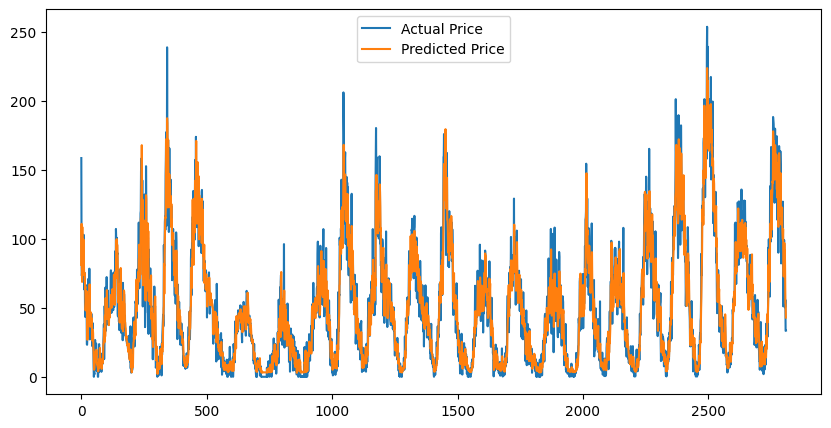

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Load Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv"

data = pd.read_csv(url)

dataset = data.iloc[:,1:2].values

# Normalize
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

# Create Sequences
x = []
y = []

time_step = 10

for i in range(time_step, len(scaled_data)):
    x.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

x = np.array(x)
y = np.array(y)

x = x.reshape((x.shape[0], x.shape[1], 1))

# Build RNN Model
model = Sequential()

model.add(SimpleRNN(64, activation='relu', input_shape=(x.shape[1],1)))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train
model.fit(
    x,
    y,
    epochs=100,
    batch_size=16,
    verbose=1
)

# Predict
predictions = model.predict(x)

predictions = scaler.inverse_transform(predictions)
real = scaler.inverse_transform(y.reshape(-1,1))

# Accuracy
rmse = np.sqrt(mean_squared_error(real, predictions))

accuracy = 100 - (rmse / np.mean(real) * 100)

print("Accuracy :", round(accuracy,2), "%")

# Plot
plt.figure(figsize=(10,5))

plt.plot(real, label='Actual Price')
plt.plot(predictions, label='Predicted Price')

plt.legend()
plt.show()

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3988
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2188 
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0914 
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0229 
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023 
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.0558e-04 
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016     
Epoch 9/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3055e-04
Epoch 10/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.0496e-04 
Epoch 11/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4813e-04 
Epoch 12/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3613e-04 
Epoch 13/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5715e-05  
Epoch 14/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1559e-05 
Epoch 15/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.7548e-

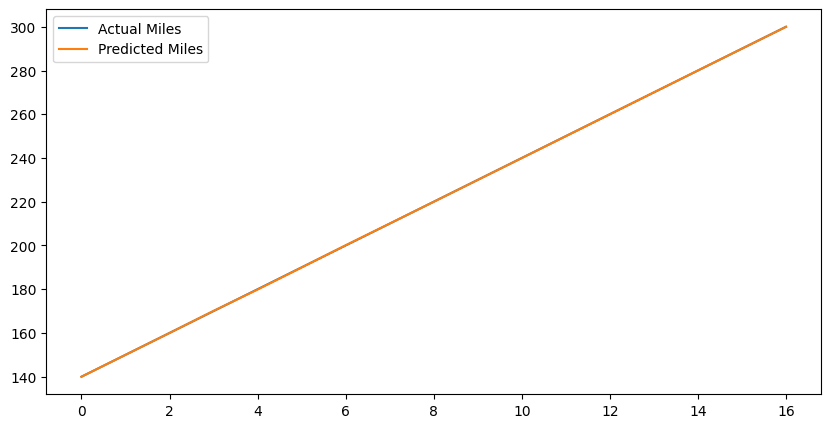

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Create Sample Dataset
data = {
    'Miles': [
        120,130,128,140,150,160,170,180,190,200,
        210,220,230,240,250,260,270,280,290,300
    ]
}

df = pd.DataFrame(data)

dataset = df[['Miles']].values

# Normalize
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

# Create Sequences
x = []
y = []

time_step = 3

for i in range(time_step, len(scaled_data)):
    x.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

x = np.array(x)
y = np.array(y)

x = x.reshape((x.shape[0], x.shape[1], 1))

# Build RNN
model = Sequential()

model.add(SimpleRNN(64, activation='relu', input_shape=(x.shape[1],1)))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train
model.fit(
    x,
    y,
    epochs=200,
    batch_size=2,
    verbose=1
)

# Predict
predictions = model.predict(x)

predictions = scaler.inverse_transform(predictions)
real = scaler.inverse_transform(y.reshape(-1,1))

# Accuracy
rmse = np.sqrt(mean_squared_error(real, predictions))

accuracy = 100 - (rmse / np.mean(real) * 100)

print("Accuracy :", round(accuracy,2), "%")

# Plot
plt.figure(figsize=(10,5))

plt.plot(real, label='Actual Miles')
plt.plot(predictions, label='Predicted Miles')

plt.legend()
plt.show()